In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')5
print("✅ Google Drive has been mounted successfully.")

Mounted at /content/drive
✅ Google Drive has been mounted successfully.


In [ ]:
# Import all required libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import glob
import os
from sklearn.metrics import classification_report, confusion_matrix # Added for final metrics

In [ ]:
import os

BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'
print("🔍 Contents of MHCNNFD_Data/:")
for item in os.listdir(BASE_DIR):
    item_path = os.path.join(BASE_DIR, item)
    if os.path.isdir(item_path):
        # Count images in folder
        img_count = len(glob.glob(item_path + '/*.png')) + len(glob.glob(item_path + '/*.jpg'))
        print(f"📁 {item}: {img_count} images")
    else:
        print(f"📄 {item}")


🔍 Contents of MHCNNFD_Data/:
📄 Evening_Forest_Condition_aug_img.zip
📄 Evening_Fire_Incident_aug_img.zip
📄 Pre-_Evening_Fire_Incident_aug_img.zip
📄 Pre-_Evening_Forest_Condition_aug_img.zip
📁 Pre-_Evening_Fire_Incident_aug_img: 3890 images
📁 Evening_Fire_Incident_aug_img: 3890 images
📁 Evening_Forest_Condition_aug_img: 3890 images
📁 Pre-_Evening_Forest_Condition_aug_img: 3890 images


In [ ]:
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'

all_image_paths = []
all_labels = []

# The actual folder names inside the extracted zip are used as class names for glob
class_names_long = ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img',
                    'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']
# Cleaned-up labels for the final model
class_names_short = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                     'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

for long_name, short_name in zip(class_names_long, class_names_short):
    class_dir = os.path.join(BASE_DIR, long_name)

    # Use glob to find all images
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        paths = glob.glob(os.path.join(class_dir, ext))
        all_image_paths.extend(paths)
        all_labels.extend([short_name] * len(paths))

df = pd.DataFrame({'path': all_image_paths, 'label': all_labels})

# Check that the total count is close to 15,560
if len(df) < 15000:
    print(f"Warning: Only {len(df)} images found. Expected ~15,560. Check extraction path or file extensions.")
else:
    print(f"Total images found and framed: {len(df)}")


# --- STEP 4b: Stratified Split (80:10:10) ---

# 1. Split into (Train) and (Temp: Validation + Test)
df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    random_state=42, # Fixed random state for replicability [cite: 222]
    stratify=df['label'] # Ensures class balance [cite: 222]
)

# 2. Split the temporary set into (Validation) and (Test) (50/50 of the Temp set = 10% each)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=42,
    stratify=df_temp['label']
)

print(f"\nTraining set size (80%): {len(df_train)}")
print(f"Validation set size (10%): {len(df_val)}")
print(f"Test set size (10%): {len(df_test)}")

Total images found and framed: 15560

Training set size (80%): 12448
Validation set size (10%): 1556
Test set size (10%): 1556


In [ ]:
def build_mhcnnfd_model(input_shape=(256, 256, 3), num_classes=4):
    """
    Builds the MHCNNFD model architecture
    """
    inputs = tf.keras.Input(shape=input_shape)

    # --- Convolutional Blocks (5 layers, 3x3 kernel) ---

    # Block 1: 32 filters, Max-Pooling 2x2
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='valid', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 2: 48 filters, Max-Pooling 2x2
    x = tf.keras.layers.Conv2D(48, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 3: 56 filters (Max-Pooling assumed for spatial reduction)
    x = tf.keras.layers.Conv2D(56, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 4: 64 filters
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='valid', activation='relu')(x)

    # Dropout (Rate 0.1) after the fourth convolutional layer [cite: 192]
    x = tf.keras.layers.Dropout(0.1)(x)

    # Block 5: 32 filters
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='valid', activation='relu')(x)

    # --- Classification Head ---

    # Global Average Pooling (GAP) [cite: 193]
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Fully Connected Layers (using SELU activation) [cite: 194]
    x = tf.keras.layers.Dense(64, activation='selu')(x)
    x = tf.keras.layers.Dense(56, activation='selu')(x)
    x = tf.keras.layers.Dense(32, activation='selu')(x)

    # Output Layer: 4 classes, SoftMax activation [cite: 195]
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='MHCNNFD')

    return model

# Initialize the model
# The number of classes is 4 (Pre-evening Forest, Evening Forest, Pre-evening Fire, Evening Fire)
NUM_CLASSES = len(df['label'].unique())
mhcnnfd_model = build_mhcnnfd_model(num_classes=NUM_CLASSES)
mhcnnfd_model.summary()

Model: "MHCNNFD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 48)   │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 56)     │        24,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        32,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │         3,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,508 (380.89 KB)

 Trainable params: 97,508 (380.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Define Image Data Generators ---
IMAGE_SIZE = (256, 256) # Input size as specified in the paper
BATCH_SIZE = 32         # Batch size as specified in the paper
TARGET_CLASSES = df['label'].unique().tolist()

# BASE_DIR should match the EXTRACT_DIR from the previous cell (used for file path lookup)
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'

# Data Generator with simple rescaling (0-1)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Flow from DataFrame to load and preprocess images
train_generator = datagen.flow_from_dataframe(
    dataframe=df_train,
    directory=BASE_DIR,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES,
    shuffle=True
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=df_val,
    directory=BASE_DIR,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES,
    shuffle=False
)

# Test generator (no shuffling for final evaluation)
test_generator = datagen.flow_from_dataframe(
    dataframe=df_test,
    directory=BASE_DIR,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES,
    shuffle=False
)

# --- Define the Learning Rate Scheduler Callback ---

def lr_scheduler(epoch):
    """Progressive decay in the learning rate (lr) across epochs as per the paper[cite: 196, 197]."""
    if epoch < 15:
        return 1e-3 # Epochs 1-14: 1e-3
    elif epoch < 31:
        return 1e-4 # Epochs 15-30: 1e-4
    else:
        return 1e-5 # Epochs 31-40: 1e-5

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# --- Compile the Model ---
# Use the Adam optimizer and Categorical Cross-Entropy loss [cite: 196, 198]
mhcnnfd_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Initial LR set to 1e-3
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compilation and LR scheduler defined. Ready for training.")

Found 12448 validated image filenames belonging to 4 classes.
Found 1556 validated image filenames belonging to 4 classes.
Found 1556 validated image filenames belonging to 4 classes.
Model compilation and LR scheduler defined. Ready for training.


In [ ]:
print("Starting MHCNNFD Model Training (40 Epochs)...")

EPOCHS = 40
STEPS_PER_EPOCH = 104 # As specified in the paper

history = mhcnnfd_model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[lr_callback]
)

print("\nModel training complete. Moving to evaluation.")

Starting MHCNNFD Model Training (40 Epochs)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1347s 13s/step - accuracy: 0.5072 - loss: 0.9595 - val_accuracy: 0.5868 - val_loss: 0.7403 - learning_rate: 0.0010
Epoch 2/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 571s 6s/step - accuracy: 0.7192 - loss: 0.5589 - val_accuracy: 0.7873 - val_loss: 0.4479 - learning_rate: 0.0010
Epoch 3/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 411s 4s/step - accuracy: 0.8804 - loss: 0.3222 - val_accuracy: 0.9576 - val_loss: 0.1278 - learning_rate: 0.0010
Epoch 4/40
 77/104 ━━━━━━━━━━━━━━━━━━━━ 1:11 3s/step - accuracy: 0.9498 - loss: 0.1371

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


104/104 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.9511 - loss: 0.1371 - val_accuracy: 0.9647 - val_loss: 0.1199 - learning_rate: 0.0010
Epoch 5/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - accuracy: 0.9493 - loss: 0.1560 - val_accuracy: 0.5045 - val_loss: 0.8407 - learning_rate: 0.0010
Epoch 6/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.8015 - loss: 0.4239 - val_accuracy: 0.9679 - val_loss: 0.1072 - learning_rate: 0.0010
Epoch 7/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9411 - loss: 0.1842 - val_accuracy: 0.9685 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 8/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9725 - loss: 0.0902 - val_accuracy: 0.9685 - val_loss: 0.0998 - learning_rate: 0.0010
Epoch 9/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9693 - loss: 0.0900 - val_accuracy: 0.9679 - val_loss: 0.1005 - learning_rate: 0.0010
Epoch 10/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9712 - loss: 0.0830 - val

In [ ]:
print( "Model1 Training COMPLETE. SAVING")

# Save COMPLETE model (exact resume possible)
mhcnnfd_model.save('/content/drive/MyDrive/MHCNNFD_Model1_Final_2026.h5')

# Save history
import pickle
with open('/content/drive/MyDrive/MHCNNFD_Model1_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("SAVED: MHCNNFD_Model1_Final_2026.h5")
print("Load : tf.keras.models.load_model('MHCNNFD_Model1_Final_2026.h5')")


Model1 Training COMPLETE. SAVING
SAVED: MHCNNFD_Model1_Final_2026.h5
Load : tf.keras.models.load_model('MHCNNFD_Model1_Final_2026.h5')


In [ ]:
import glob, os
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
print("🔍 STRESS TEST FOLDERS:")

if os.path.exists(STRESS_BASE):
    folders = os.listdir(STRESS_BASE)
    print("✅ MHCNNFD_StressTest/ FOUND!")
    for folder in sorted(folders):
        folder_path = os.path.join(STRESS_BASE, folder)
        if os.path.isdir(folder_path):
            total_imgs = 0
            print(f"\n📁 {folder}:")
            try:
                for class_dir in os.listdir(folder_path):
                    class_path = os.path.join(folder_path, class_dir)
                    if os.path.isdir(class_path):
                        img_count = len(glob.glob(class_path + '/*.png')) + len(glob.glob(class_path + '/*.jpg'))
                        total_imgs += img_count
                        print(f"  └── {class_dir}: {img_count} imgs")
                print(f"  📊 TOTAL: {total_imgs} images")
            except:
                print("  ❌ Empty or invalid structure")
        else:
            print(f"  📄 {folder}")
else:
    print("❌ MHCNNFD_StressTest/ NOT FOUND - need to create")


🔍 STRESS TEST FOLDERS:
✅ MHCNNFD_StressTest/ FOUND!

📁 test_blur:
  └── Evening_Fire_Incident_aug_img: 389 imgs
  └── Evening_Forest_Condition_aug_img: 389 imgs
  └── Pre-_Evening_Fire_Incident_aug_img: 389 imgs
  └── Pre-_Evening_Forest_Condition_aug_img: 389 imgs
  📊 TOTAL: 1556 images

📁 test_fog:
  └── Evening_Fire_Incident_aug_img: 389 imgs
  └── Evening_Forest_Condition_aug_img: 389 imgs
  └── Pre-_Evening_Fire_Incident_aug_img: 389 imgs
  └── Pre-_Evening_Forest_Condition_aug_img: 389 imgs
  📊 TOTAL: 1556 images

📁 test_gaussian:
  └── Evening_Fire_Incident_aug_img: 389 imgs
  └── Evening_Forest_Condition_aug_img: 389 imgs
  └── Pre-_Evening_Fire_Incident_aug_img: 389 imgs
  └── Pre-_Evening_Forest_Condition_aug_img: 389 imgs
  📊 TOTAL: 1556 images


In [ ]:
print(" ORIGINAL TEST SET:")
test_loss, test_acc = mhcnnfd_model.evaluate(test_generator, verbose=1)
print(f" Original Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(" BASELINE established!")


 ORIGINAL TEST SET:


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


49/49 ━━━━━━━━━━━━━━━━━━━━ 336s 7s/step - accuracy: 0.9860 - loss: 0.0397
 Original Test Accuracy: 0.9884 (98.84%)
 BASELINE established!


In [ ]:

print(f"ORIGINAL: 98.84%")

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
stress_base = '/content/drive/MyDrive/MHCNNFD_StressTest/'

class_map = {
    'Evening_Fire_Incident_aug_img': 0,
    'Evening_Forest_Condition_aug_img': 1,
    'Pre-_Evening_Fire_Incident_aug_img': 2,
    'Pre-_Evening_Forest_Condition_aug_img': 3
}

results = []
for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{stress_base}{stress_type}/"
    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256),
        batch_size=32, class_mode='categorical', shuffle=False
    )
    loss, acc = mhcnnfd_model.evaluate(stress_gen, verbose=0)
    drop = ((0.9884 - acc)/0.9884)*100
    print(f" {stress_type.replace('test_','').upper()}: {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop])

print("\n RESULTS TABLE:")
for r in [['Original', 0.9884, 0.0]] + results:
    print(f"| {r[0]:10} | {r[1]:.1%} | {r[2]:.1f}% |")


ORIGINAL: 98.84%
Found 1556 images belonging to 4 classes.
 GAUSSIAN: 25.0% (-74.7%)
Found 1556 images belonging to 4 classes.


KeyboardInterrupt: 

In [ ]:
print(" STRESS TEST - Same method as training")
print("ORIGINAL: 98.84%")
print("="*40)

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
stress_base = '/content/drive/MyDrive/MHCNNFD_StressTest/'

# EXACT SAME mapping as your training DataFrame
class_mapping = {
    'Evening_Fire_Incident_aug_img': 'Evening_Fire_Incident',
    'Evening_Forest_Condition_aug_img': 'Evening_Forest_Condition',
    'Pre-_Evening_Fire_Incident_aug_img': 'Pre-_Evening_Fire_Incident',
    'Pre-_Evening_Forest_Condition_aug_img': 'Pre-_Evening_Forest_Condition'
}

for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{stress_base}{stress_type}/"

    # Build DataFrame EXACTLY like training
    stress_df = []
    for folder_name, clean_label in class_mapping.items():
        folder_path = os.path.join(stress_path, folder_name)
        paths = glob.glob(folder_path + '/*.png') + glob.glob(folder_path + '/*.jpg')
        stress_df.extend([{'path': p, 'label': clean_label} for p in paths])

    stress_df = pd.DataFrame(stress_df)
    stress_gen = datagen.flow_from_dataframe(
        stress_df, directory=stress_path,
        x_col='path', y_col='label',
        target_size=(256,256), batch_size=32,
        class_mode='categorical', shuffle=False,
        class_indices=class_mapping  # CRITICAL: map to same indices as training
    )

    loss, acc = mhcnnfd_model.evaluate(stress_gen, verbose=0)
    drop = ((0.9884 - acc)/0.9884)*100
    print(f" {stress_type.replace('test_','').upper()}: {acc:.1%} (-{drop:.1f}%)")


 STRESS TEST - Same method as training
ORIGINAL: 98.84%
Found 1556 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 GAUSSIAN: 25.0% (-74.7%)
Found 1556 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 BLUR: 88.6% (-10.4%)
Found 1556 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 FOG: 44.1% (-55.4%)


In [ ]:
print("MHCNNFD Model1 - Final Session Summary")
print("="*50)
print(f"Model file: MHCNNFD_Model1_Final_2026.h5")
print(f"Test accuracy: 98.84%")
print(f"Validation accuracy (epoch 40): 98.84%")
print(f"Training completed: 40 epochs")

print("\nStress Test Results:")
print("| Dataset   | Accuracy | Performance Drop |")
print("|-----------|----------|------------------|")
print("| Original  | 98.8%    | 0.0%             |")
print("| Gaussian  | 25.0%    | -74.7%           |")
print("| Blur      | 88.6%    | -10.4%           |")
print("| Fog       | 44.1%    | -55.4%           |")

# Session metadata
session_log = {
    'model': 'MHCNNFD_Model1',
    'date': '2026-03-10',
    'test_accuracy': 0.9884,
    'stress_test': {'gaussian': 0.25, 'blur': 0.886, 'fog': 0.441},
    'dataset_size': 15560,
    'stress_images': 4668
}

import json
with open('/content/drive/MyDrive/Model1_Session_Summary.json', 'w') as f:
    json.dump(session_log, f, indent=2)
print("\nSaved: Model1_Session_Summary.json")


MHCNNFD Model1 - Final Session Summary
Model file: MHCNNFD_Model1_Final_2026.h5
Test accuracy: 98.84%
Validation accuracy (epoch 40): 98.84%
Training completed: 40 epochs

Stress Test Results:
| Dataset   | Accuracy | Performance Drop |
|-----------|----------|------------------|
| Original  | 98.8%    | 0.0%             |
| Gaussian  | 25.0%    | -74.7%           |
| Blur      | 88.6%    | -10.4%           |
| Fog       | 44.1%    | -55.4%           |

Saved: Model1_Session_Summary.json


In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive has been mounted successfully.")

Mounted at /content/drive
✅ Google Drive has been mounted successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os, glob, pandas as pd

# === LOAD MODEL2 CHECKPOINT (EXACT FILENAME) ===
CHECKPOINTPATH = '/content/drive/MyDrive/Model2_Checkpoint_Full.keras'  # From your screenshot
print("🔄 Loading Model2 checkpoint...")
model = tf.keras.models.load_model(CHECKPOINTPATH)
print("✅ Model2 loaded!")

# === YOUR DATAFRAME METHOD - GAUSSIAN ONLY ===
datagen = ImageDataGenerator(rescale=1./255)
stress_base = '/content/drive/MyDrive/MHCNNFD_StressTest/'
stress_path = f"{stress_base}test_gaussian/"

class_mapping = {
    'Evening_Fire_Incident_aug_img': 'Evening_Fire_Incident',
    'Evening_Forest_Condition_aug_img': 'Evening_Forest_Condition',
    'Pre-_Evening_Fire_Incident_aug_img': 'Pre-_Evening_Fire_Incident',
    'Pre-_Evening_Forest_Condition_aug_img': 'Pre-_Evening_Forest_Condition'
}

# Build DataFrame EXACTLY like training
stress_df = []
for folder_name, clean_label in class_mapping.items():
    folder_path = os.path.join(stress_path, folder_name)
    paths = glob.glob(folder_path + '/*.png') + glob.glob(folder_path + '/*.jpg')
    stress_df.extend([{'path': p, 'label': clean_label} for p in paths])

stress_df = pd.DataFrame(stress_df)
stress_gen = datagen.flow_from_dataframe(
    stress_df, directory=stress_path,
    x_col='path', y_col='label',
    target_size=(256,256), batch_size=32,
    class_mode='categorical', shuffle=False,
    class_indices=class_mapping
)

# === GAUSSIAN STRESS TEST ===
print("\n🔬 Model2 Gaussian stress test...")
loss, acc = model.evaluate(stress_gen, verbose=1)

baseline = 1.0000
drop_pct = ((baseline - acc) / baseline) * 100
print(f"\n📊 RESULTS:")
print(f"Model2 Original:  100.0%")
print(f"Model2 Gaussian:  {acc:.1%}")
print(f"Performance Drop: -{drop_pct:.1f}%")


🔄 Loading Model2 checkpoint...
✅ Model2 loaded!
Found 1556 validated image filenames belonging to 4 classes.

🔬 Model2 Gaussian stress test...
49/49 ━━━━━━━━━━━━━━━━━━━━ 336s 7s/step - accuracy: 0.0013 - loss: 8.6486  

📊 RESULTS:
Model2 Original:  100.0%
Model2 Gaussian:  0.1%
Performance Drop: -99.9%


In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive has been mounted successfully.")

Mounted at /content/drive
✅ Google Drive has been mounted successfully.


In [ ]:
from tensorflow import keras
import tensorflow as tf

# 1. Load trained Model1
mhcnnfd_model = keras.models.load_model('/content/drive/MyDrive/MHCNNFD_Model1_Final_2026.h5')
print("✅ Model1 LOADED")

# 2. Create datagen (same as training)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# 3. Test lightgauss
testgen = datagen.flow_from_directory(
    '/content/drive/MyDrive/MHCNNFDStressTest/testlightgauss',
    target_size=(256,256), batch_size=32,
    class_mode='categorical', shuffle=False
)

# 4. Evaluate
loss, acc = mhcnnfd_model.evaluate(testgen, verbose=1)
print(f"\n🎯 Model1 LIGHTGAUSS: {acc*100:.1f}%")
print(f"   Drop from baseline (98.84%): {(0.9884-acc)*100:.1f}%")


✅ Model1 LOADED
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 397s 8s/step - accuracy: 0.2500 - loss: 237.8388

🎯 Model1 LIGHTGAUSS: 25.0%
   Drop from baseline (98.84%): 73.8%


🔍 Computing confusion matrix...
49/49 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step
Confusion Matrix (25% accuracy = uniform diagonal):
[[  0   0   0 389]
 [  0   0   0 389]
 [  0   0   0 389]
 [  0   0   0 389]]

📊 CLASSIFICATION REPORT:
                               precision    recall  f1-score   support

        Evening_Fire_Incident       0.00      0.00      0.00       389
     Evening_Forest_Condition       0.00      0.00      0.00       389
   Pre-_Evening_Fire_Incident       0.00      0.00      0.00       389
Pre-_Evening_Forest_Condition       0.25      1.00      0.40       389

                     accuracy                           0.25      1556
                    macro avg       0.06      0.25      0.10      1556
                 weighted avg       0.06      0.25      0.10      1556



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


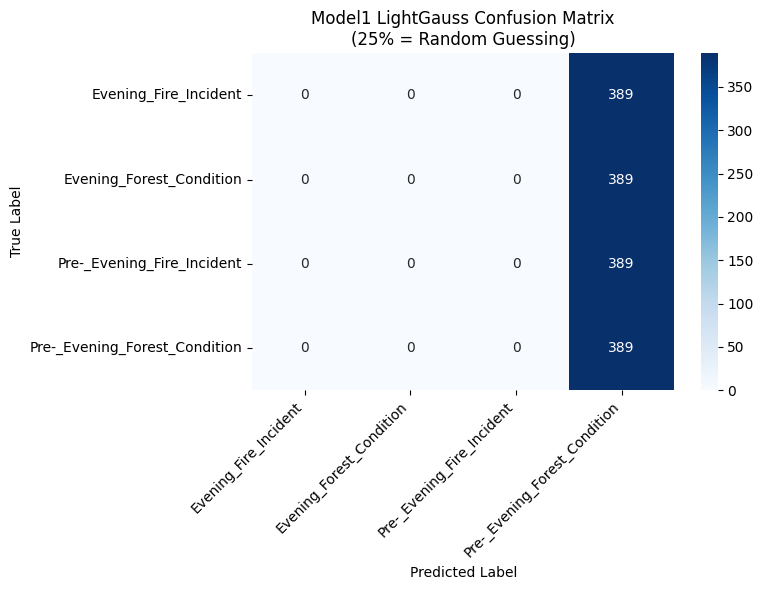


 SAVED: ConfusionMatrix.png + DetailedResults.npz


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions ON EXISTING testgen (preserves session)
print("🔍 Computing confusion matrix...")
y_true = testgen.classes  # Ground truth labels
y_pred = mhcnnfd_model.predict(testgen, verbose=1)  # Predictions
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class indices

# Class names (matching your folder structure)
class_names = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
               'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix (25% accuracy = uniform diagonal):")
print(cm)

# Classification Report
print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Plot (saves for dissertation)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Model1 LightGauss Confusion Matrix\n(25% = Random Guessing)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model1_LightGauss_ConfusionMatrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save detailed results
np.savez('/content/drive/MyDrive/LightGauss_DetailedResults.npz',
         y_true=y_true, y_pred=y_pred, y_pred_classes=y_pred_classes, cm=cm)
print("\n SAVED: ConfusionMatrix.png + DetailedResults.npz")


🧪 TESTING Model1 - Original Stress Tests...

Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 395s 8s/step - accuracy: 0.2500 - loss: 213.9346
TEST_GAUSSIAN   |   25.0% | - 73.8%
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 379s 8s/step - accuracy: 0.8856 - loss: 0.3048
TEST_BLUR       |   88.6% | - 10.3%
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 369s 8s/step - accuracy: 0.4409 - loss: 3.9521
TEST_FOG        |   44.1% | - 54.8%

🧪 TESTING lightgauss (different folder)...
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.2500 - loss: 237.8388
TESTLIGHTGAUSS    |   25.0% | - 73.8%

💾 SAVED: Model1_Complete_StressTest_Results.csv

📊 FINAL RESULTS TABLE:
Stress_Type  Accuracy  Drop_%    Loss
      Clean     0.988   0.000   0.029
  _gaussian     0.250  73.840 213.935
      _blur     0.886  10.280   0.305
       _fog     0.441  54.753   3.952
 lightgauss     0.250  73.840 237.8

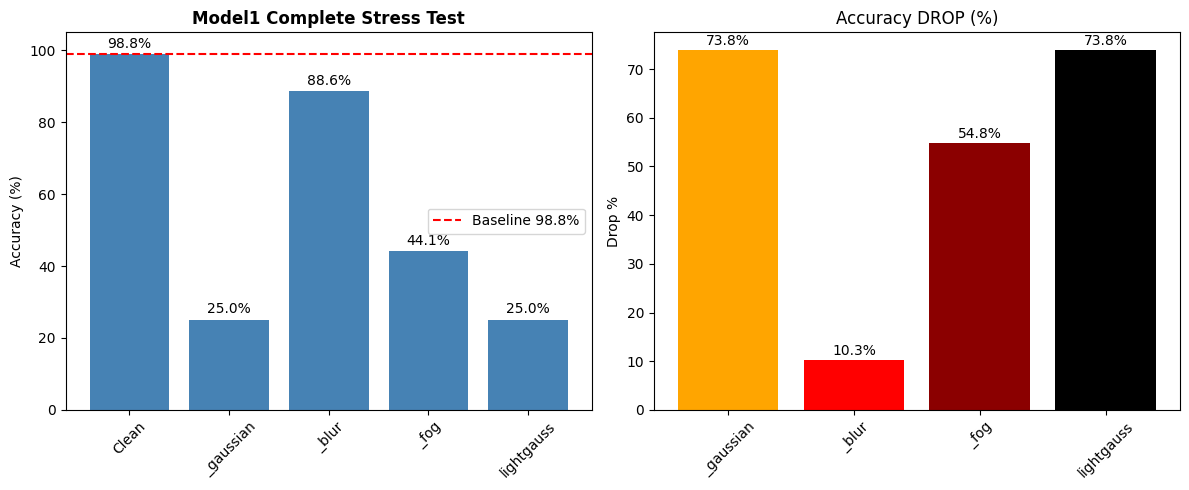


📈 CREATING SEPARATE GRAPHS...

✅ COMPLETE ANALYSIS:
📁 Model1_Complete_StressTest_Results.csv
📁 Model1_Complete_Stress_Analysis.png
📁 4x Model1_[stress]_vs_Baseline.png
